# Front Co-location & Visualization

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
import xarray as xr
import pandas as pd
from pathlib import Path
import json, re
from scipy.stats import gaussian_kde
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from fronts.properties.colocation import colocate_fronts_with_properties


plt.rcParams['figure.figsize'] = (16, 9)
plt.rcParams['font.size'] = 10
%matplotlib inline

print('Imports OK')

Imports OK


## 1. Load Pre-Computed Results

In [8]:
# ─── FILE PATHS & TAGS ──────────────────────────────────────
import numpy as np
from pathlib import Path
from datetime import datetime

# Configure output path and run tag
output_dir = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/group_fronts/v1/'
run_tag = 'v1_bin_A'  # Update this to match your run

# Construct time string and file paths
time_str_safe = '20121109T12_00_00'
labeled_file = str(Path(output_dir) / f'labeled_fronts_global_{time_str_safe}_{run_tag}.npy')
geometry_file = str(Path(output_dir) / f'global_front_geometry_{time_str_safe}_{run_tag}.parquet')
metadata_file = str(Path(output_dir) / f'metadata_{time_str_safe}_{run_tag}.json')

print(f"Loading from: {labeled_file}")
print(f"Run tag: {run_tag}")

# Load labeled fronts array
labeled_fronts = np.load(labeled_file)
geometry_data = pd.read_parquet(geometry_file)
print(f'df_global: {len(geometry_data):,} fronts × {len(geometry_data.columns)} cols')
print(f'  Columns: {list(geometry_data.columns)}')

import json
with open(metadata_file, 'r') as f:
    metadata = json.load(f)

print(f"Labeled fronts shape: {labeled_fronts.shape}")
print(f"Geometry keys: {list(geometry_data.keys())}")
print(f"Metadata keys: {list(metadata.keys())}")

Loading from: /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/group_fronts/v1/labeled_fronts_global_20121109T12_00_00_v1_bin_A.npy
Run tag: v1_bin_A
df_global: 135,654 fronts × 19 cols
  Columns: ['label', 'name', 'time', 'npix', 'y0', 'y1', 'x0', 'x1', 'centroid_lat', 'centroid_lon', 'length_km', 'orientation', 'num_branches', 'lat_min', 'lat_max', 'lon_min', 'lon_max', 'mean_curvature', 'curvature_direction']
Labeled fronts shape: (12960, 17280)
Geometry keys: ['label', 'name', 'time', 'npix', 'y0', 'y1', 'x0', 'x1', 'centroid_lat', 'centroid_lon', 'length_km', 'orientation', 'num_branches', 'lat_min', 'lat_max', 'lon_min', 'lon_max', 'mean_curvature', 'curvature_direction']
Metadata keys: ['fronts_file', 'run_tag', 'time', 'shape', 'num_fronts', 'n_workers', 'skip_curvature', 'lat_range', 'lon_range', 'timestamp']


## 2. Load Physical Property Maps

In [9]:
# ─── SETTINGS ────────────────────────────────────────────────────────────────
properties_dir = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/derived'
version        = '1'
timestamp      = '2012-11-09T12_00_00'

property_names = [
    'gradb2',
    'gradtheta2',
    'gradeta2',
    'gradsalt2',
    'relative_vorticity',
    'strain_mag',
    'okubo_weiss',
    'divergence',
    'coriolis_f',
    'frontogenesis_tendency',
]

# Files auto-resolved as: {properties_dir}/LLC4320_{timestamp}_{prop_name}_v{version}.nc
# ─────────────────────────────────────────────────────────────────────────────

property_files = {
    name: (
        str(Path(properties_dir) / f'LLC4320_{timestamp}_{name}_v{version}.nc'),
        name,
    )
    for name in property_names
}

print(f"Configured to load {len(property_files)} properties:")
for name in property_names:
    print(f"  - {name}")

Configured to load 10 properties:
  - gradb2
  - gradtheta2
  - gradeta2
  - gradsalt2
  - relative_vorticity
  - strain_mag
  - okubo_weiss
  - divergence
  - coriolis_f
  - frontogenesis_tendency


In [11]:
import xarray as xr
from fronts.properties.colocation import _load_property_file

# Load coordinates
downsample_factor = 1
coords_file  = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/lohoff/group_fronts/LLC_coords_lat_lon.nc'
ds_coords  = xr.open_dataset(coords_file)
lat_global = ds_coords['lat'].values if 'lat' in ds_coords else ds_coords['YC'].values
lon_global = ds_coords['lon'].values if 'lon' in ds_coords else ds_coords['XC'].values
ds_coords.close()
if downsample_factor:
    lat_global = lat_global[::downsample_factor, ::downsample_factor]
    lon_global = lon_global[::downsample_factor, ::downsample_factor]

# Roll arrays so columns run -180 → +180
sample_row  = lat_global.shape[0] // 2
min_lon_col = int(np.argmin(lon_global[sample_row, :]))
shift       = -min_lon_col
if min_lon_col != 0:
    print(f'Rolling by {shift} cols to align longitude axis')
    lon_global    = np.roll(lon_global,    shift, axis=1)
    lat_global    = np.roll(lat_global,    shift, axis=1)
    labeled_global = np.roll(labeled_fronts, shift, axis=1)
else:
    print('No rolling needed')

print(f'\n✓ Pre-computed results loaded.  Array shape: {labeled_fronts.shape}')

property_arrays = {}
for prop_name, src in property_files.items():
    arr = _load_property_file(src)          # handles .nc tuples, .npy, or arrays
    arr = arr.squeeze()                      # drop any singleton time/depth dims
    if downsample_factor:
        arr = arr[::downsample_factor, ::downsample_factor]
    if min_lon_col != 0:                     # same longitude roll as labeled array
        arr = np.roll(arr, shift, axis=1)
    property_arrays[prop_name] = arr
    src_label = src[0] if isinstance(src, (list, tuple)) else (
                    str(src) if not isinstance(src, np.ndarray) else '<array>')
    print(f"  {prop_name:25s}  shape={arr.shape}  "
          f"range=[{float(np.nanmin(arr)):.3g}, {float(np.nanmax(arr)):.3g}]")

print(f'\n✓ {len(property_arrays)} property arrays loaded and aligned')

Rolling by -10464 cols to align longitude axis

✓ Pre-computed results loaded.  Array shape: (12960, 17280)
  gradb2                     shape=(12960, 17280)  range=[4.79e-25, 1.58e-09]
  gradtheta2                 shape=(12960, 17280)  range=[2.95e-23, 1.43e-05]
  gradeta2                   shape=(12960, 17280)  range=[3.29e-21, 5.89e-05]
  gradsalt2                  shape=(12960, 17280)  range=[0, 2.57e-05]
  relative_vorticity         shape=(12960, 17280)  range=[-0.00158, 0.00118]
  strain_mag                 shape=(12960, 17280)  range=[8.58e-10, 0.00311]
  okubo_weiss                shape=(12960, 17280)  range=[-1.92e-06, 9.39e-06]
  divergence                 shape=(12960, 17280)  range=[-0.00123, 0.00143]
  coriolis_f                 shape=(12960, 17280)  range=[-0.000146, 0.000139]
  frontogenesis_tendency     shape=(12960, 17280)  range=[-5.32e-14, 9e-14]

✓ 10 property arrays loaded and aligned


## 3. Co-locate Fronts with Properties

In [13]:
# ─── CO-LOCATION SETTINGS ────────────────────────────────────────────────────
USE_DILATION    = True   # Dilate each front mask before extracting stats?
DILATION_RADIUS = 3       # Dilation radius in pixels (Euclidean disk);
                          #   only used when USE_DILATION=True
STATS           = ['mean', 'std', 'median']  # any of: mean std median min max count
PERCENTILES     = [10, 90]                   # additional percentile columns
MIN_NPIX        = 5        # skip fronts smaller than this many pixels
NAN_POLICY      = 'omit'   # 'omit' ignores NaN (land/cloud); 'propagate' is faster
# ─────────────────────────────────────────────────────────────────────────────

print('Running co-location…')
df_coloc = colocate_fronts_with_properties(
    labeled_global,
    property_arrays,
    stats=STATS,
    percentiles=PERCENTILES,
    min_npix=MIN_NPIX,
    nan_policy=NAN_POLICY,
    dilation_radius=DILATION_RADIUS if USE_DILATION else 0,
)
print(f'  Co-location complete: {len(df_coloc):,} fronts × {len(df_coloc.columns)} cols')
print(f'  New columns: {[c for c in df_coloc.columns if c not in ("flabel","npix")]}')

# Merge physical stats into geometric properties table
df_enriched = geometry_data.merge(df_coloc, left_on='label', right_on='flabel', how='inner')
# Resolve duplicate npix columns (geometric parquet uses 'npix'; coloc adds 'npix' too)
if 'npix_x' in df_enriched.columns:
    df_enriched = df_enriched.rename(columns={'npix_x': 'npix'}).drop(columns=['npix_y'], errors='ignore')

print(f'\n✓ Enriched table: {len(df_enriched):,} fronts × {len(df_enriched.columns)} cols')
print(f'  All columns: {list(df_enriched.columns)}')
df_enriched.head(3)

Running co-location…
  Co-location complete: 135,507 fronts × 52 cols
  New columns: ['gradb2_mean', 'gradb2_std', 'gradb2_median', 'gradb2_p10', 'gradb2_p90', 'gradtheta2_mean', 'gradtheta2_std', 'gradtheta2_median', 'gradtheta2_p10', 'gradtheta2_p90', 'gradeta2_mean', 'gradeta2_std', 'gradeta2_median', 'gradeta2_p10', 'gradeta2_p90', 'gradsalt2_mean', 'gradsalt2_std', 'gradsalt2_median', 'gradsalt2_p10', 'gradsalt2_p90', 'relative_vorticity_mean', 'relative_vorticity_std', 'relative_vorticity_median', 'relative_vorticity_p10', 'relative_vorticity_p90', 'strain_mag_mean', 'strain_mag_std', 'strain_mag_median', 'strain_mag_p10', 'strain_mag_p90', 'okubo_weiss_mean', 'okubo_weiss_std', 'okubo_weiss_median', 'okubo_weiss_p10', 'okubo_weiss_p90', 'divergence_mean', 'divergence_std', 'divergence_median', 'divergence_p10', 'divergence_p90', 'coriolis_f_mean', 'coriolis_f_std', 'coriolis_f_median', 'coriolis_f_p10', 'coriolis_f_p90', 'frontogenesis_tendency_mean', 'frontogenesis_tendency_std

,label,name,time,npix,y0,y1,x0,x1,centroid_lat,centroid_lon,...,coriolis_f_mean,coriolis_f_std,coriolis_f_median,coriolis_f_p10,coriolis_f_p90,frontogenesis_tendency_mean,frontogenesis_tendency_std,frontogenesis_tendency_median,frontogenesis_tendency_p10,frontogenesis_tendency_p90
0,5086,20121109TT120000_71.8S_13.4W,2012-11-09T12:00:00,10,2676,2683,1177,1186,-71.820587,-13.350595,...,-0.000139,2.243476e-08,-0.000139,-0.000139,-0.000139,1.456371e-20,1.815663e-19,7.844987e-22,-1.626500e-19,2.116991e-19
1,5087,20121109TT120000_71.7S_176.7W,2012-11-09T12:00:00,27,2676,2687,10604,10624,-71.718987,-176.749710,...,-0.000138,2.539697e-08,-0.000138,-0.000139,-0.000138,-2.965164e-20,2.546968e-19,-3.569592e-21,-3.241801e-19,2.769440e-19
2,5088,20121109TT120000_71.6S_161.8W,2012-11-09T12:00:00,9,2676,2681,11332,11339,-71.565338,-161.754669,...,-0.000138,1.542445e-08,-0.000138,-0.000138,-0.000138,1.415453e-20,4.966767e-20,8.766537e-22,-1.120090e-20,4.675536e-20


## 4. Select Region for Visualization

In [14]:
# ─── VISUALISATION REGION ────────────────────────────────────────────────────
VISUALIZE_ENTIRE_GLOBE = False      # Option A: whole globe 

USE_LATLON_BOUNDS = False           # Option B: explicit lat/lon bounds
region_bounds = dict(lat_min=-10, lat_max=10, lon_min=-180, lon_max=-160)

USE_PIXEL_REGION = True             # Option C: pixel window around a point
pixel_region = dict(center_lat=35, center_lon=-70, height=500, width=500)
# ─────────────────────────────────────────────────────────────────────────────

if VISUALIZE_ENTIRE_GLOBE:
    i_min, i_max = 0, labeled_global.shape[0]
    j_min, j_max = 0, labeled_global.shape[1]
    region_bounds = dict(lat_min=lat_global.min(), lat_max=lat_global.max(),
                         lon_min=lon_global.min(), lon_max=lon_global.max())

elif USE_LATLON_BOUNDS:
    mask  = ((lat_global >= region_bounds['lat_min']) & (lat_global <= region_bounds['lat_max']) &
             (lon_global >= region_bounds['lon_min']) & (lon_global <= region_bounds['lon_max']))
    r, c  = np.where(mask)
    i_min, i_max = r.min(), r.max() + 1
    j_min, j_max = c.min(), c.max() + 1

elif USE_PIXEL_REGION:
    dist_centre   = np.hypot(lat_global - pixel_region['center_lat'],
                             lon_global - pixel_region['center_lon'])
    ci, cj = np.unravel_index(np.argmin(dist_centre), dist_centre.shape)
    hh, hw = pixel_region['height']//2, pixel_region['width']//2
    i_min = max(0, ci-hh);  i_max = min(labeled_global.shape[0], ci+hh)
    j_min = max(0, cj-hw);  j_max = min(labeled_global.shape[1], cj+hw)
    region_bounds = dict(lat_min=lat_global[i_min:i_max, j_min:j_max].min(),
                         lat_max=lat_global[i_min:i_max, j_min:j_max].max(),
                         lon_min=lon_global[i_min:i_max, j_min:j_max].min(),
                         lon_max=lon_global[i_min:i_max, j_min:j_max].max())

# Regional slices
sl = (slice(i_min, i_max), slice(j_min, j_max))
labeled_viz = labeled_global[sl]
lat_viz     = lat_global[sl]
lon_viz     = lon_global[sl]
prop_viz    = {k: v[sl] for k, v in property_arrays.items()}

# Filter enriched table to region (by centroid)
df_region = df_enriched[
    (df_enriched['centroid_lat'] >= region_bounds['lat_min']) &
    (df_enriched['centroid_lat'] <= region_bounds['lat_max']) &
    (df_enriched['centroid_lon'] >= region_bounds['lon_min']) &
    (df_enriched['centroid_lon'] <= region_bounds['lon_max'])
].copy()

print(f'Region: lat=[{region_bounds["lat_min"]:.2f}, {region_bounds["lat_max"]:.2f}]  '
      f'lon=[{region_bounds["lon_min"]:.2f}, {region_bounds["lon_max"]:.2f}]')
print(f'Array window: {labeled_viz.shape}')
print(f'Fronts in region: {len(df_region):,} / {len(df_enriched):,} global')

Region: lat=[30.97, 38.82]  lon=[-75.22, -64.82]
Array window: (500, 500)
Fronts in region: 249 / 135,507 global


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
# After this point you don't need to run every cell, just the one/s you wish to plot
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

## 5. Global Context Map

Shows where the selected region sits on the globe.

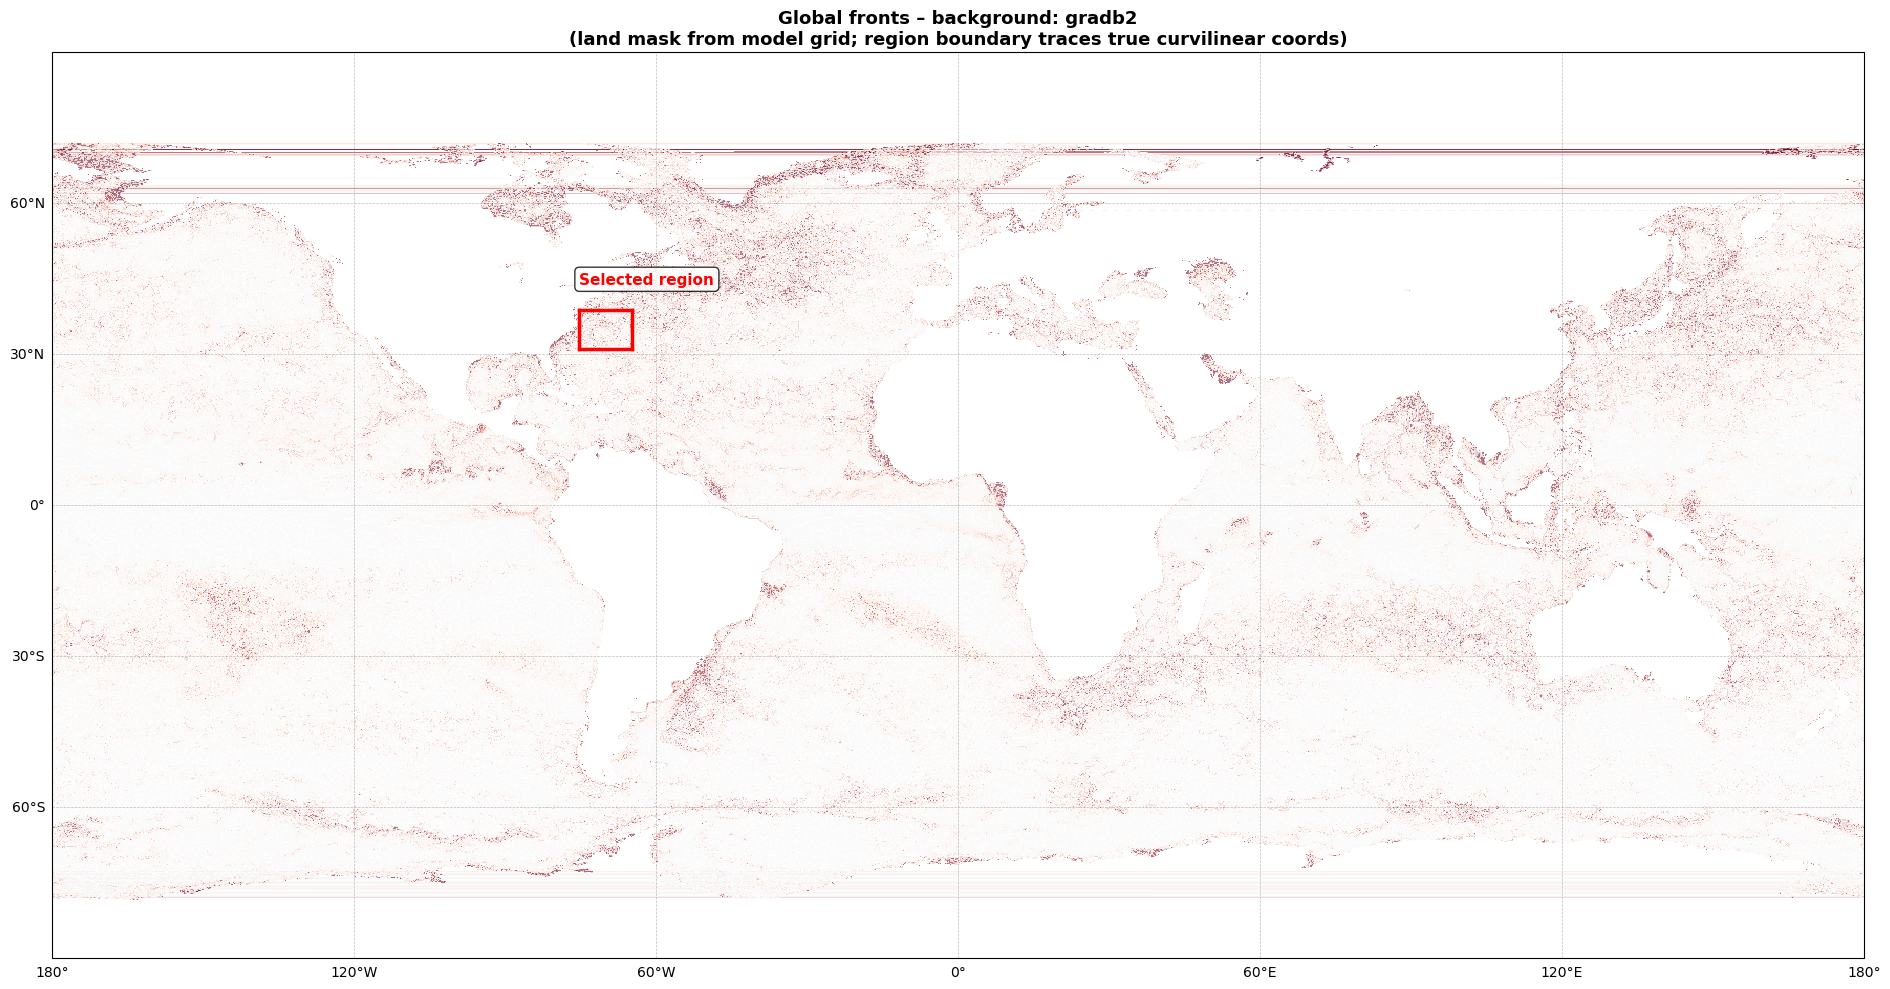

In [15]:
# ─── DISPLAY SETTINGS ─────────────────────────────────────────────
GLOBAL_DS       = 10      # display downsample (1-in-N pixels); increase if slow
GLOBAL_BG_PROP  = list(property_arrays.keys())[0]  # property shown as background
GLOBAL_BG_CMAP  = 'RdBu_r'
GLOBAL_BG_PCT   = 95      # symmetric percentile clip for the background colorscale
# ─────────────────────────────────────────────────────────────────────────────

ds     = GLOBAL_DS
lat_ds = lat_global[::ds, ::ds]
lon_ds = lon_global[::ds, ::ds]
bg_ds  = property_arrays[GLOBAL_BG_PROP][::ds, ::ds].astype(float)

# --- Front pixels: dilate BEFORE downsampling so 1-px fronts survive ---
from scipy.ndimage import maximum_filter
front_binary  = (labeled_global > 0).astype(np.uint8)
front_dilated = maximum_filter(front_binary, size=ds)
front_ds      = front_dilated[::ds, ::ds].astype(float)
front_ds[front_ds == 0] = np.nan             # mask background (transparent)

# --- Land mask: pixels where ALL properties are NaN (model land/ice) ---
land_ds = np.all(np.stack(
    [np.isnan(v[::ds, ::ds]) for v in property_arrays.values()], axis=0), axis=0
).astype(float)
land_ds[land_ds == 0] = np.nan               # mask ocean (transparent)

# Symmetric percentile clip for the background field
finite_bg = bg_ds[np.isfinite(bg_ds) & (land_ds != 1 if np.any(np.isfinite(land_ds)) else True)]
clip_val  = float(np.nanpercentile(np.abs(finite_bg), GLOBAL_BG_PCT)) if len(finite_bg) else 1.0

tfm = ccrs.PlateCarree() 


fig, ax = plt.subplots(1, 1, figsize=(20, 10),
                        subplot_kw={'projection': ccrs.PlateCarree()})
pcm_kw = dict(transform=tfm, rasterized=True)

# 1. Background property field (true curvilinear lat/lon)
ax.pcolormesh(lon_ds, lat_ds, bg_ds,
                cmap=GLOBAL_BG_CMAP, vmin=-clip_val, vmax=clip_val,
                alpha=0.55, **pcm_kw)

# 2. Land mask (gray, opaque)
ax.pcolormesh(lon_ds, lat_ds, np.ma.masked_invalid(land_ds),
                cmap='Greys', vmin=0, vmax=1, alpha=1.0, **pcm_kw)

# 3. Front pixels (dark) -- dilated so they survive downsampling
ax.pcolormesh(lon_ds, lat_ds, np.ma.masked_invalid(front_ds),
                cmap='Greys_r', vmin=0, vmax=1, alpha=0.7, **pcm_kw)

# True-degree gridlines
gl = ax.gridlines(crs=tfm, draw_labels=True,
                    linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels   = False
gl.right_labels = False
ax.set_global()
# Optional -- uncomment once Natural Earth shapefiles are locally cached:
# import cartopy.feature as cfeature
# ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color='k', zorder=4)


# Selected-region boundary: plot ACTUAL curvilinear perimeter
if not VISUALIZE_ENTIRE_GLOBE:
    edges = [
        (lon_global[i_min,    j_min:j_max],  lat_global[i_min,    j_min:j_max]),
        (lon_global[i_max-1,  j_min:j_max],  lat_global[i_max-1,  j_min:j_max]),
        (lon_global[i_min:i_max, j_min],     lat_global[i_min:i_max, j_min]),
        (lon_global[i_min:i_max, j_max-1],   lat_global[i_min:i_max, j_max-1]),
    ]
    plot_kw = dict(color='red', linewidth=2.5, zorder=5)
    plot_kw['transform'] = tfm
    for elon, elat in edges:
        ax.plot(elon, elat, **plot_kw)
    txt_kw = dict(color='red', fontsize=11, fontweight='bold', zorder=6,
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    txt_kw['transform'] = tfm
    ax.text(lon_global[i_min, j_min], lat_global[i_min, j_min] + 13,
            'Selected region', **txt_kw)

ax.set_title(f'Global fronts – background: {GLOBAL_BG_PROP}\n'
             f'(land mask from model grid; region boundary traces true curvilinear coords)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Regional Map: Property Field + Fronts Overlay

The **background** shows the raw property field as a 2-D image.
Fronts are overlaid, optionally colour-coded by a per-front statistic.

Change `MAP_BG_PROPERTY`, `FRONT_COLOR_BY`, and `FRONT_COLOR_MODE` below.

/home/lhoffma2/miniforge3/envs/fronts/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


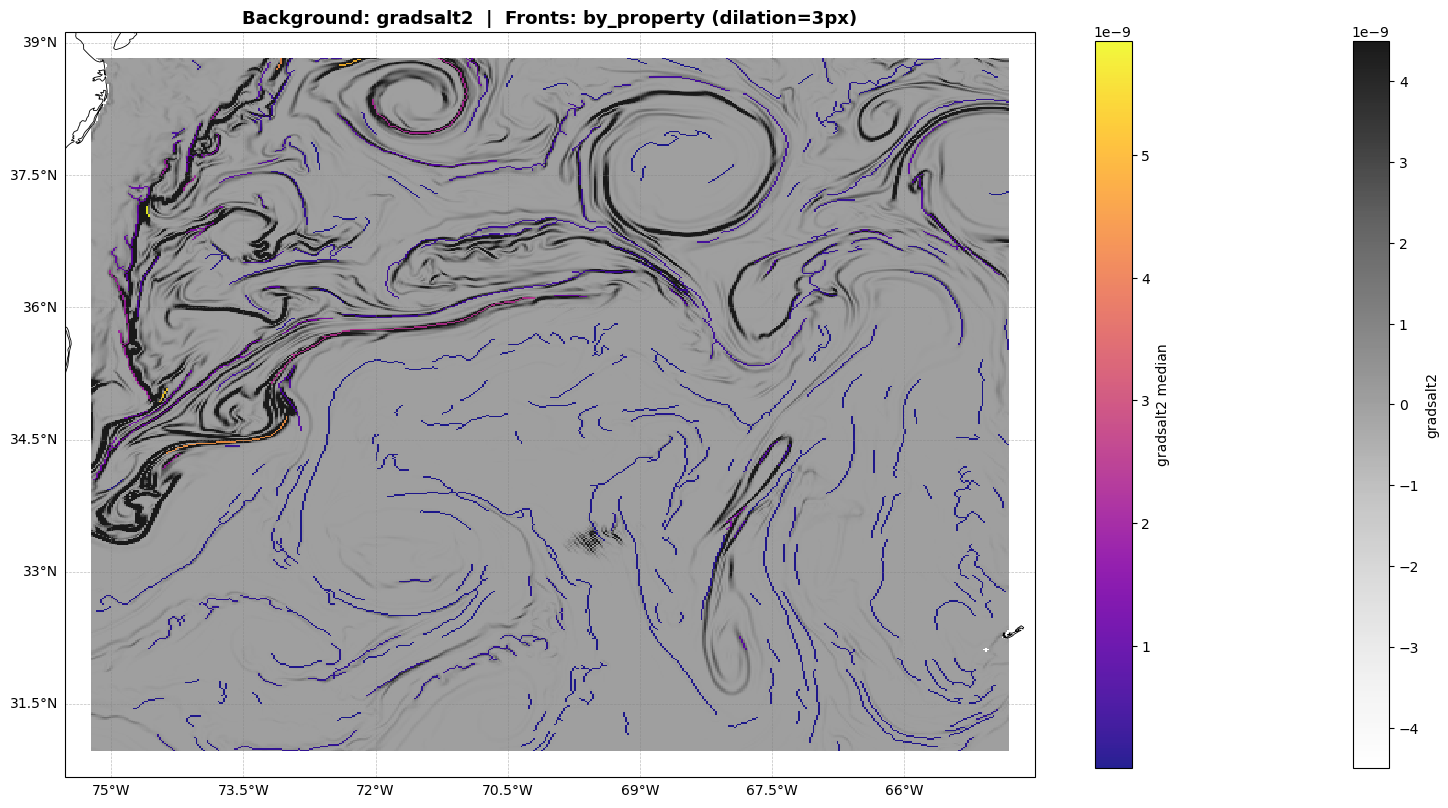

In [16]:
# ─── MAP SETTINGS ────────────────────────────────────────────────────────────
MAP_BG_PROPERTY   = 'gradsalt2'  # raw 2-D field used as background
MAP_BG_CMAP       = 'Greys'
MAP_BG_PCT_CLIP   = 97               # symmetric percentile clip

FRONT_COLOR_MODE  = 'by_property'    # 'by_property' | 'uniform' | 'random'
FRONT_COLOR_BY    = 'gradsalt2_median'  # per-front stat (only for 'by_property')
FRONT_CMAP        = 'plasma'
FRONT_ALPHA       = 0.9
# ─────────────────────────────────────────────────────────────────────────────

# Build front overlay as a 2-D array (NaN = background/land)
front_mask = labeled_viz > 0
front_data = np.full(labeled_viz.shape, np.nan)

if FRONT_COLOR_MODE == 'uniform':
    front_data[front_mask] = 1.0
    front_cmap_kw = dict(cmap='Reds_r', vmin=0, vmax=1.5)
    add_front_cbar = False

elif FRONT_COLOR_MODE == 'random':
    ulbls         = np.unique(labeled_viz[front_mask])
    rng_r         = np.random.default_rng(42)
    lut_r         = np.full(int(labeled_viz.max()) + 1, np.nan)
    lut_r[ulbls]  = rng_r.random(len(ulbls))
    front_data    = lut_r[labeled_viz].copy()
    front_data[~front_mask] = np.nan
    front_cmap_kw = dict(cmap='tab20')
    add_front_cbar = False

else:  # by_property
    if FRONT_COLOR_BY not in df_region.columns:
        raise ValueError(f'{FRONT_COLOR_BY!r} not in df_region. '
                         f'Available: {list(df_region.columns)}')
    prop_series = df_region.set_index('label')[FRONT_COLOR_BY].dropna()
    max_lbl     = int(labeled_viz.max())
    lut_v       = np.full(max_lbl + 1, np.nan)
    for lbl, val in prop_series.items():
        if 0 < lbl <= max_lbl: lut_v[lbl] = val
    front_data  = lut_v[labeled_viz].copy()
    front_data[~front_mask] = np.nan
    valid        = front_data[front_mask & ~np.isnan(front_data)]
    front_cmap_kw = dict(cmap=FRONT_CMAP,
                         vmin=np.nanmin(valid) if len(valid) else 0,
                         vmax=np.nanmax(valid) if len(valid) else 1)
    add_front_cbar = len(valid) > 0

# Land mask from model grid in this region
land_viz = np.all(np.stack(
    [np.isnan(v) for v in prop_viz.values()], axis=0), axis=0
).astype(float)
land_viz[land_viz == 0] = np.nan

# ── Figure setup (cartopy for true geographic labelling) ─────────────────
tfm = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(16, 10),
                        subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([lon_viz.min() - 0.3, lon_viz.max() + 0.3,
                lat_viz.min() - 0.3, lat_viz.max() + 0.3], crs=tfm)
gl = ax.gridlines(crs=tfm, draw_labels=True,
                    linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False; gl.right_labels = False

import cartopy.feature as cfeature
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='k', zorder=5)
pcm_kw = dict(transform=tfm, rasterized=True)


# Background: raw property field on the TRUE curvilinear lat/lon grid
bg   = prop_viz[MAP_BG_PROPERTY].astype(float)
clip = np.nanpercentile(np.abs(bg[np.isfinite(bg)]), MAP_BG_PCT_CLIP)
pm_bg = ax.pcolormesh(lon_viz, lat_viz, bg,
                      cmap=MAP_BG_CMAP, vmin=-clip, vmax=clip,
                      alpha=0.9, **pcm_kw)
plt.colorbar(pm_bg, ax=ax, label=MAP_BG_PROPERTY.replace('_', ' '), shrink=0.75)

# Land mask (gray, drawn over background)
ax.pcolormesh(lon_viz, lat_viz, np.ma.masked_invalid(land_viz),
              cmap='Greys', vmin=0, vmax=1, alpha=1.0, **pcm_kw)

# Front overlay
pm_f = ax.pcolormesh(lon_viz, lat_viz,
                     np.ma.masked_invalid(front_data),
                     alpha=FRONT_ALPHA, **{**pcm_kw, **front_cmap_kw})
if add_front_cbar:
    plt.colorbar(pm_f, ax=ax, shrink=0.75,
                 label=FRONT_COLOR_BY.replace('_', ' '))

dil_tag = f' (dilation={DILATION_RADIUS}px)' if USE_DILATION else ''
ax.set_title(f'Background: {MAP_BG_PROPERTY}  |  '
             f'Fronts: {FRONT_COLOR_MODE}{dil_tag}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. PDFs of Per-Front Properties in Selected Region

Each panel shows the distribution of a per-front statistic for fronts
whose centroid falls inside the selected region.
Add or remove entries in `PDF_PROPS` to change what is plotted.

⚠️  Skipping unavailable columns: {'rossby_number_mean'}


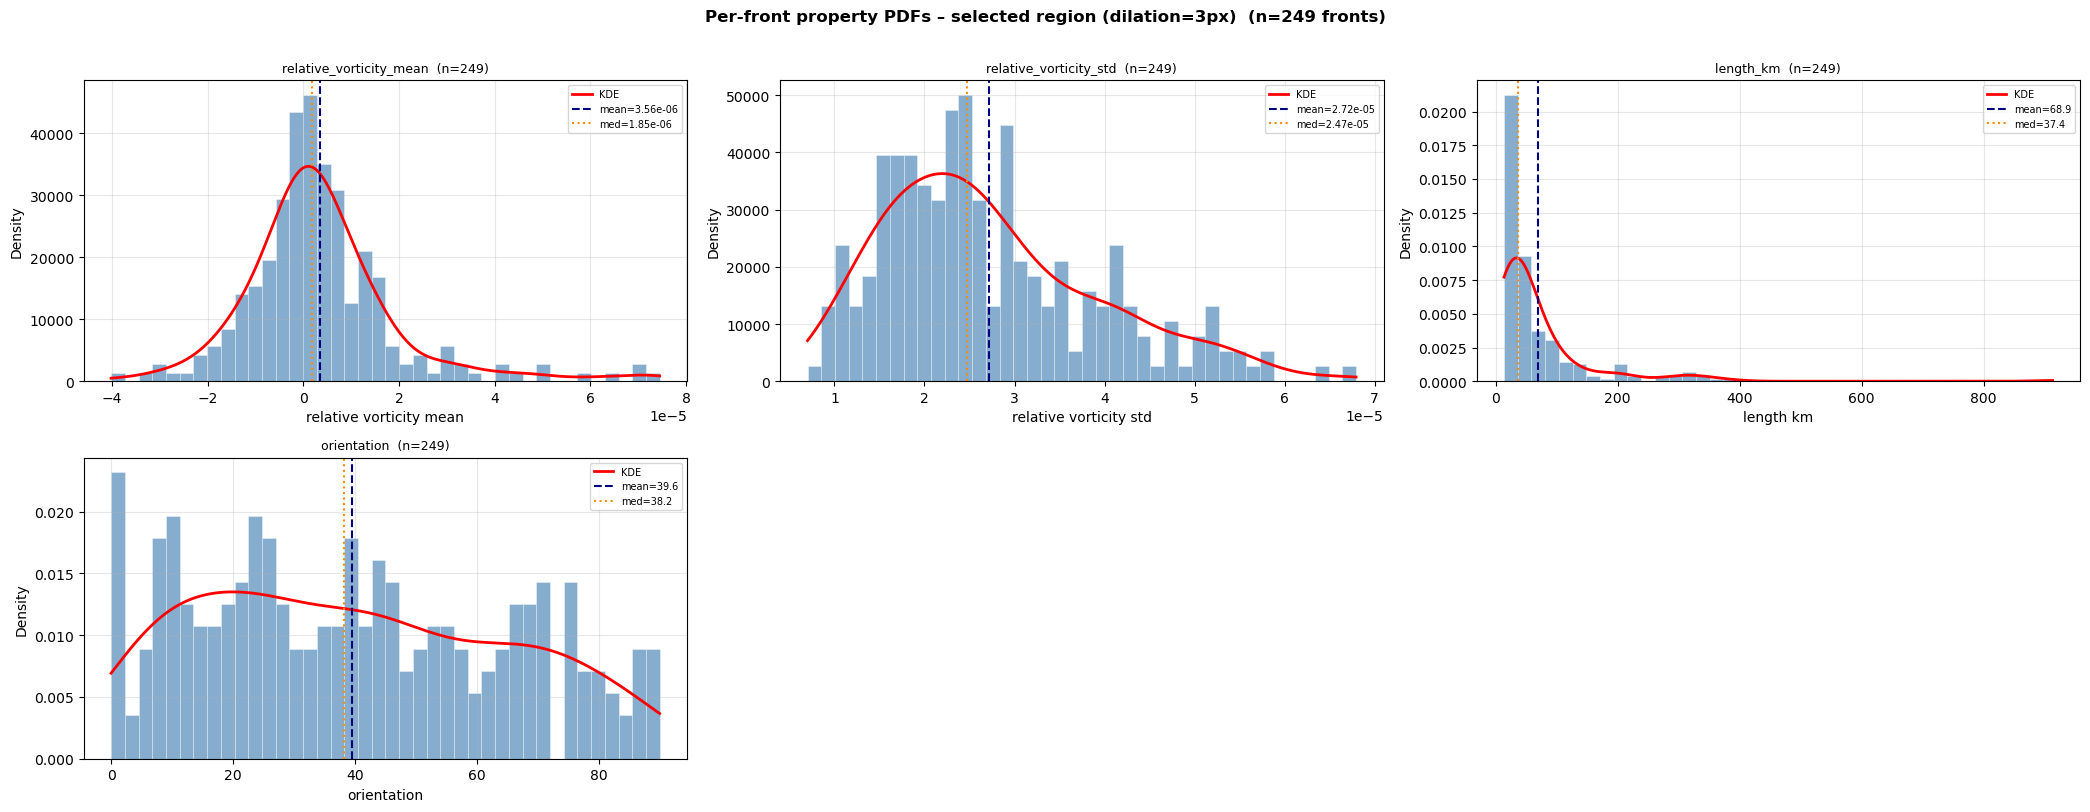

In [17]:
# ─── PDF SETTINGS ────────────────────────────────────────────────────────────
# Any column in df_region (geometric or co-located physical property stat)
PDF_PROPS = [
    'relative_vorticity_mean',   # mean relative vorticity of each front
    'relative_vorticity_std',    # within-front variability
    'rossby_number_mean',        # mean Rossby number
    'length_km',                 # geometric (from pre-computed parquet)
    'orientation',               # geometric
    # Add any column from df_region, e.g.:
    # 'SSH_mean', 'strain_rate_mean', 'relative_vorticity_p10', ...
]
PDF_NCOLS    = 3
PDF_BINS     = 40
PDF_SHOW_KDE = True     # overlay KDE curve
# ─────────────────────────────────────────────────────────────────────────────

# Remove entries that are not actually present
pdf_avail = [p for p in PDF_PROPS if p in df_region.columns]
if len(pdf_avail) < len(PDF_PROPS):
    missing_p = set(PDF_PROPS) - set(pdf_avail)
    print(f'⚠️  Skipping unavailable columns: {missing_p}')

nrows = int(np.ceil(len(pdf_avail) / PDF_NCOLS))
fig, axes = plt.subplots(nrows, PDF_NCOLS, figsize=(7*PDF_NCOLS, 4*nrows))
axes_flat  = np.array(axes).flatten()

for idx, prop in enumerate(pdf_avail):
    ax   = axes_flat[idx]
    data = df_region[prop].dropna()
    ax.hist(data, bins=PDF_BINS, density=True, alpha=0.65,
            color='steelblue', edgecolor='white', linewidth=0.4)
    if PDF_SHOW_KDE and len(data) > 20:
        try:
            kde = gaussian_kde(data)
            xs  = np.linspace(data.min(), data.max(), 300)
            ax.plot(xs, kde(xs), 'r-', lw=2, label='KDE')
        except Exception:
            pass
    ax.axvline(data.mean(),   color='navy', ls='--', lw=1.5, label=f'mean={data.mean():.3g}')
    ax.axvline(data.median(), color='darkorange', ls=':', lw=1.5,
               label=f'med={data.median():.3g}')
    ax.set_title(f'{prop}  (n={len(data):,})', fontsize=9)
    ax.set_xlabel(prop.replace('_', ' ')); ax.set_ylabel('Density')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

for idx in range(len(pdf_avail), len(axes_flat)):
    axes_flat[idx].set_visible(False)

dil_tag = f' (dilation={DILATION_RADIUS}px)' if USE_DILATION else ''
fig.suptitle(f'Per-front property PDFs – selected region{dil_tag}  '
             f'(n={len(df_region):,} fronts)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 8. Scatter Plots – Global Front Catalogue

These plots use **all globally detected fronts** (not just the region).
Edit `SCATTER_PAIRS` to explore different variable combinations.
Each tuple is `(x_column, y_column, color_column_or_None)`.

In [18]:
# ─── SCATTER SETTINGS ─────────────────────────────────────────────────────────
# Each row: (x_column, y_column, color_by_or_None)
# x/y can be ANY column in df_enriched (geometric props + co-location stats)
SCATTER_PAIRS = [
    ('relative_vorticity_mean', 'gradb2_mean',  None),
    ('strain_mag_mean',     'gradb2_mean',      None),
    ('okubo_weiss_mean',   'gradb2_mean',     None),
    #('length_km',     'relative_vorticity_mean', None),
    # ('strain_mag_mean',     'relative_vorticity_mean', 'gradb2_mean'),
    #('centroid_lon',  'centroid_lat',      'strain_mag_std'),
    # More examples — uncomment or add your own:
    # ('centroid_lat', 'SSH_mean',                    None),
    # ('orientation',  'relative_vorticity_std',      'rossby_number_mean'),
    # ('length_km',    'relative_vorticity_p90',      None),
]

SCATTER_ALPHA   = 0.25      # point transparency (lower = better for dense clouds)
SCATTER_SIZE    = 1.5       # marker size
SCATTER_CMAP    = 'viridis' # colormap used when color_by is not None
N_SAMPLE        = None    # subsample for speed; set None to use all fronts
# ─────────────────────────────────────────────────────────────────────────────

Plotting all 135,507 fronts


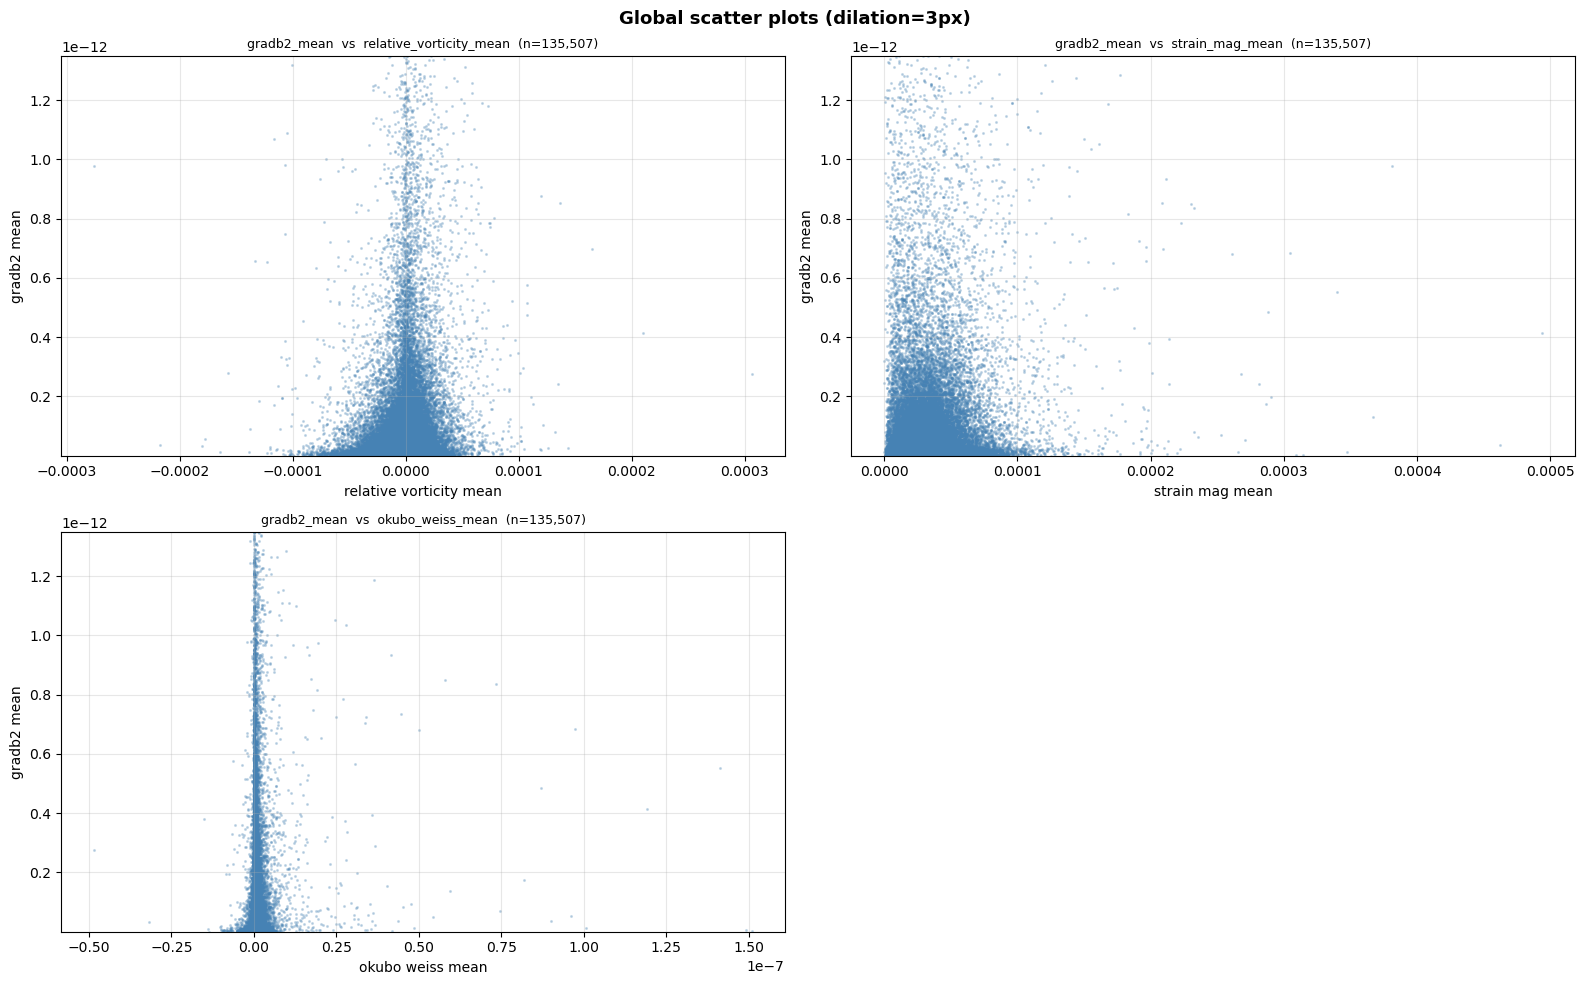

In [19]:
# Subsample for fast rendering
if N_SAMPLE and len(df_enriched) > N_SAMPLE:
    df_plot = df_enriched.sample(N_SAMPLE, random_state=42)
    print(f'Plotting {N_SAMPLE:,} / {len(df_enriched):,} fronts (random subsample)')
else:
    df_plot = df_enriched
    print(f'Plotting all {len(df_enriched):,} fronts')

# Filter to pairs whose columns actually exist
valid_pairs = []
for (xc, yc, cc) in SCATTER_PAIRS:
    missing_cols = [c for c in [xc, yc] + ([cc] if cc else [])
                    if c not in df_plot.columns]
    if missing_cols:
        print(f'  ⚠️  Skipping ({xc}, {yc}): missing columns {missing_cols}')
    else:
        valid_pairs.append((xc, yc, cc))

ncols = min(2, len(valid_pairs))
nrows = int(np.ceil(len(valid_pairs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(8*ncols, 5*nrows))
axes_flat  = np.array(axes).flatten() if len(valid_pairs) > 1 else [axes]

for idx, (xc, yc, cc) in enumerate(valid_pairs):
    ax   = axes_flat[idx]
    sub  = df_plot[[xc, yc] + ([cc] if cc else [])].dropna()
    if cc:
        sc = ax.scatter(sub[xc], sub[yc], c=sub[cc],
                        cmap=SCATTER_CMAP, s=SCATTER_SIZE, alpha=SCATTER_ALPHA,
                        rasterized=True)
        plt.colorbar(sc, ax=ax, label=cc.replace('_', ' '), shrink=0.8)
    else:
        ax.scatter(sub[xc], sub[yc], s=SCATTER_SIZE, alpha=SCATTER_ALPHA,
                   color='steelblue', rasterized=True)
    ax.set_xlabel(xc.replace('_', ' ')); ax.set_ylabel(yc.replace('_', ' '))
    ax.set_title(f'{yc}  vs  {xc}  (n={len(sub):,})', fontsize=9)
    ax.set_ylim(sub[yc].quantile(0.00), sub[yc].quantile(0.995))
    ax.grid(True, alpha=0.3)

for idx in range(len(valid_pairs), len(axes_flat)):
    axes_flat[idx].set_visible(False)

dil_tag = f' (dilation={DILATION_RADIUS}px)' if USE_DILATION else ''
fig.suptitle(f'Global scatter plots{dil_tag}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 9. Summary Statistics

In [20]:
print('=' * 65)
print('GLOBAL CATALOGUE')
print('=' * 65)
print(f'  Total fronts: {len(df_enriched):,}')
phys_cols = [c for c in df_enriched.columns
             if any(c.endswith(f'_{s}') for s in ['mean','std','median'])]
if phys_cols:
    print(f'\nPer-front physical statistics (global median ± std):')
    for col in phys_cols:
        d = df_enriched[col].dropna()
        print(f'  {col:30s}  median={d.median():.3g}  std={d.std():.3g}  n={len(d):,}')

print()
print('=' * 65)
print('SELECTED REGION')
print('=' * 65)
print(f'  lat=[{region_bounds["lat_min"]:.2f}, {region_bounds["lat_max"]:.2f}]  '
      f'lon=[{region_bounds["lon_min"]:.2f}, {region_bounds["lon_max"]:.2f}]')
print(f'  Fronts: {len(df_region):,}  ({100*len(df_region)/len(df_enriched):.2f}% of global)')
if phys_cols:
    print(f'\nPer-front physical statistics (region median ± std):')
    for col in phys_cols:
        d = df_region[col].dropna()
        if len(d):
            print(f'  {col:30s}  median={d.median():.3g}  std={d.std():.3g}  n={len(d):,}')
print()

GLOBAL CATALOGUE
  Total fronts: 135,507

Per-front physical statistics (global median ± std):
  gradb2_mean                     median=7.22e-15  std=7.16e-13  n=135,507
  gradb2_std                      median=7.5e-15  std=8.67e-13  n=135,507
  gradb2_median                   median=4.18e-15  std=4.18e-13  n=135,507
  gradtheta2_mean                 median=1.01e-09  std=2.71e-08  n=135,507
  gradtheta2_std                  median=1.14e-09  std=3.88e-08  n=135,507
  gradtheta2_median               median=5.1e-10  std=1.25e-08  n=135,507
  gradeta2_mean                   median=6.54e-12  std=3.16e-08  n=135,507
  gradeta2_std                    median=4.7e-12  std=6.34e-08  n=135,507
  gradeta2_median                 median=5.03e-12  std=4.95e-09  n=135,507
  gradsalt2_mean                  median=8.46e-11  std=1.21e-08  n=135,507
  gradsalt2_std                   median=9.45e-11  std=1.47e-08  n=135,507
  gradsalt2_median                median=4.32e-11  std=7.06e-09  n=135,507
  relati